# Task 2: Exploratory Data Analysis — Ethiopia Financial Inclusion

**Author:** Sosina Ayele
**Program:** 10 Academy — Week 11 Challenge
**Project:** Forecasting Financial Inclusion in Ethiopia
**Date:** July 2026

This notebook analyzes the enriched Ethiopia financial-inclusion dataset:
dataset overview, Access (account ownership) trends, Usage (digital payments)
trends, infrastructure enablers, event-timeline overlays, correlation analysis,
and an explicit event–impact narrative. Reusable loading/analysis logic lives
in `src/data_loader.py` and `src/analysis.py`.

In [ ]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import (
    load_unified_data, load_impact_links, load_reference_codes,
    split_by_record_type, validate_against_reference
)
from analysis import (
    get_indicator_series, get_disaggregated_series, compute_growth_rates,
    merge_impact_links_with_events, find_unlinked_events,
    registered_vs_active_gap
)

sns.set_style('whitegrid')

## 0. Load Data (via `src/` modules, with validation)

In [ ]:
df = load_unified_data('../data/raw/ethiopia_fi_unified_data.csv')
impact_df = load_impact_links('../data/raw/Impact_sheet.csv')
ref = load_reference_codes('../data/raw/reference_codes.csv')

parts = split_by_record_type(df)
obs, events, targets = parts['observations'], parts['events'], parts['targets']

print(f"Observations: {len(obs)} | Events: {len(events)} | Targets: {len(targets)} | Impact links: {len(impact_df)}")

Observations: 30 | Events: 10 | Targets: 3 | Impact links: 14


In [ ]:
# Validate categorical fields against reference_codes.csv
invalid_pillars = validate_against_reference(df, ref, 'pillar')
print("Rows with pillar values not in reference_codes.csv:")
print(invalid_pillars[['record_id', 'pillar']] if not invalid_pillars.empty else "None found")

Rows with pillar values not in reference_codes.csv:
None found


**Data quality note:** `reference_codes.csv` lists four valid pillar codes
(ACCESS, USAGE, QUALITY, AFFORDABILITY). If the cell above shows GENDER rows,
that confirms the dataset uses a pillar value outside the documented reference
list — flagged in `data_enrichment_log.md` for reconciliation.

## 1. Dataset Overview

In [ ]:
print("Records by type x pillar:")
print(df.groupby(['record_type', 'pillar'], dropna=False).size())
print()
print("Records by type x source_type:")
print(df.groupby(['record_type', 'source_type'], dropna=False).size())
print()
print("Confidence distribution:")
print(df['confidence'].value_counts(dropna=False))

Records by type x pillar:
record_type  pillar       
event        NaN              10
observation  ACCESS           14
             AFFORDABILITY     1
             GENDER            4
             USAGE            11
target       ACCESS            2
             GENDER            1
dtype: int64

Records by type x source_type:
record_type  source_type
event        news            2
             operator        4
             regulator       4
observation  calculated      2
             operator       11
             regulator       3
             research        4
             survey         10
target       policy          3
dtype: int64

Confidence distribution:
confidence
high      40
medium     3
Name: count, dtype: int64


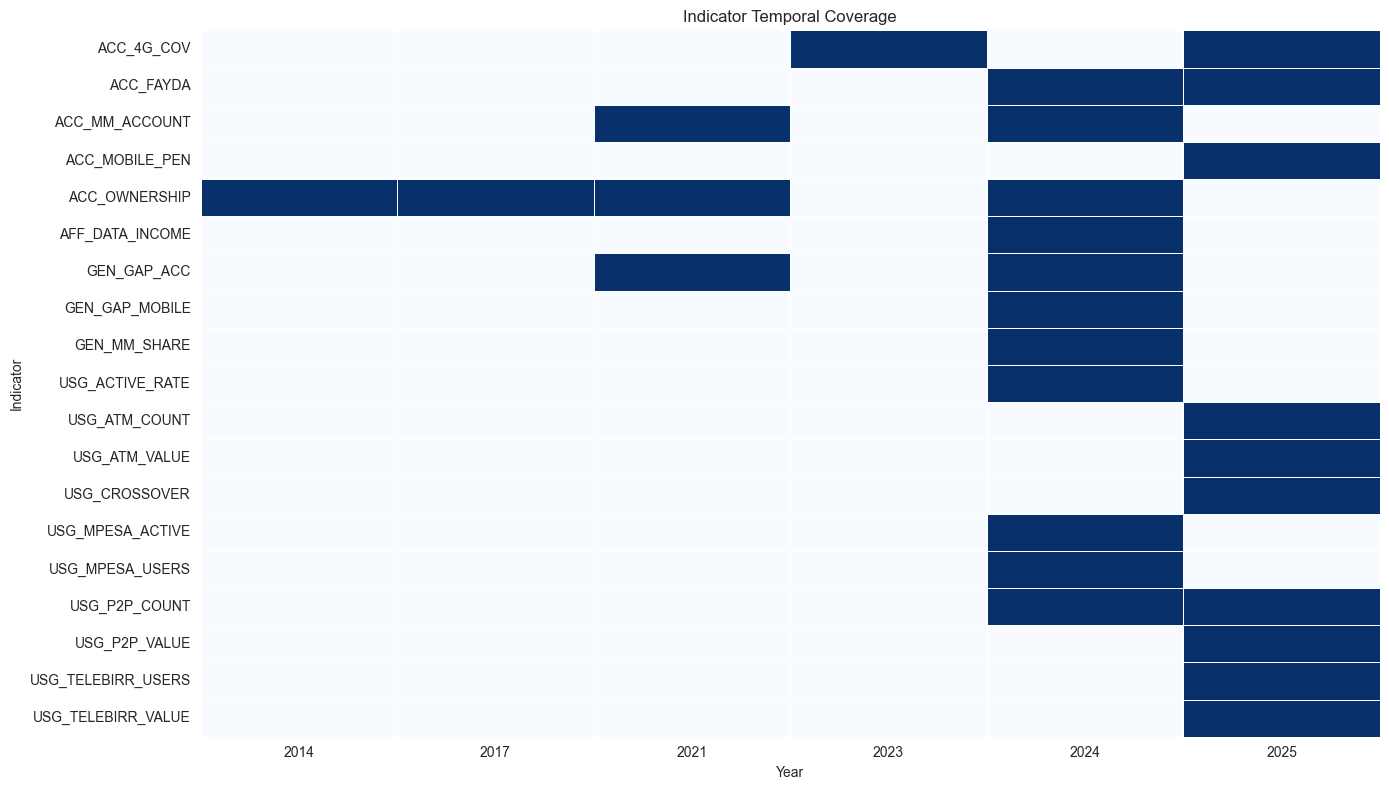

In [ ]:
obs = obs.copy()
obs['year'] = obs['observation_date'].dt.year
coverage = obs.pivot_table(index='indicator_code', columns='year', values='value_numeric', aggfunc='count')

plt.figure(figsize=(14, 8))
sns.heatmap(coverage.notna(), cmap='Blues', cbar=False, linewidths=0.5)
plt.title('Indicator Temporal Coverage')
plt.xlabel('Year'); plt.ylabel('Indicator')
plt.tight_layout()
plt.savefig('../reports/figures/temporal_coverage.png', dpi=150)
plt.show()

**Observation:** coverage is heavily skewed toward 2023–2025. Only
`ACC_OWNERSHIP` (and partially `ACC_MM_ACCOUNT` / `GEN_GAP_ACC`) has long-run
history back to 2011–2014; most Usage-pillar indicators have a single year
of data, which will limit forecast confidence for Usage relative to Access.

## 2. Access Analysis — Account Ownership Trajectory (2011–2024)

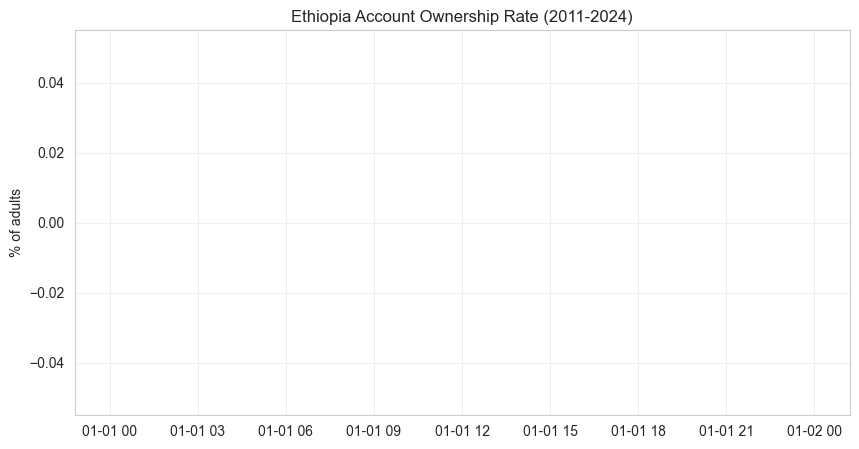

Empty DataFrame
Columns: [observation_date, value_numeric, pp_change]
Index: []


In [ ]:
# get_indicator_series excludes gender-disaggregated rows so the national
# trend is not distorted by male/female breakouts of the same survey wave
acc = get_indicator_series(obs, 'ACC_OWNERSHIP')
acc = compute_growth_rates(acc)

plt.figure(figsize=(10, 5))
plt.plot(acc['observation_date'], acc['value_numeric'], marker='o', color='#1B9AAA')
plt.title('Ethiopia Account Ownership Rate (2011-2024)')
plt.ylabel('% of adults')
plt.grid(alpha=0.3)
plt.savefig('../reports/figures/access_trajectory.png', dpi=150)
plt.show()

print(acc[['observation_date', 'value_numeric', 'pp_change']])

**Growth is decelerating:** +8pp (2011-14), +13pp (2014-17), +11pp
(2017-21), then only +3pp (2021-24) — despite mobile money expansion in the
same window. This is the "2021-2024 slowdown" the brief highlights.

### 2a. Gender Gap in Account Ownership

Gender-disaggregated account ownership:
  observation_date  gender  value_numeric
0       2014-12-31     all           22.0
1       2017-12-31     all           35.0
2       2021-12-31     all           46.0
3       2021-12-31    male           56.0
4       2021-12-31  female           36.0
5       2024-11-29     all           49.0


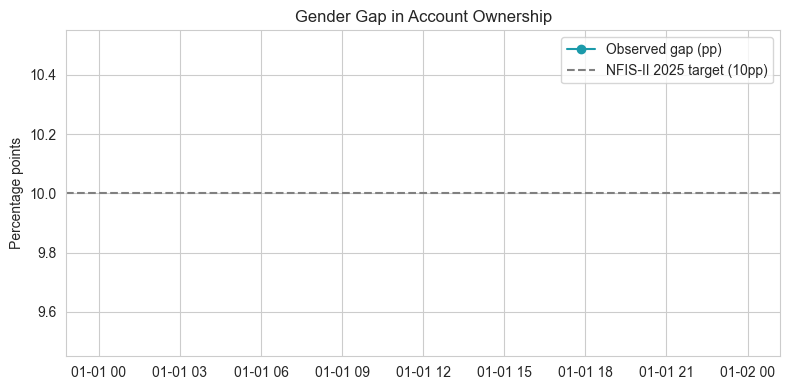

In [ ]:
gender_obs = get_disaggregated_series(obs, 'ACC_OWNERSHIP')
print("Gender-disaggregated account ownership:")
print(gender_obs[['observation_date', 'gender', 'value_numeric']])

gap = get_indicator_series(obs, 'GEN_GAP_ACC')
plt.figure(figsize=(8, 4))
plt.plot(gap['observation_date'], gap['value_numeric'], marker='o', color='#1B9AAA', label='Observed gap (pp)')
plt.axhline(10, linestyle='--', color='gray', label='NFIS-II 2025 target (10pp)')
plt.title('Gender Gap in Account Ownership')
plt.ylabel('Percentage points')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/gender_gap_trend.png', dpi=150)
plt.show()

**Gender gap status:** 15pp as of 2024 (57% men vs 42% women), only
modestly narrower than the 19pp 2020 baseline NFIS-II set out to halve to
10pp by 2025. One survey cycle remains before the deadline — the target is
at meaningful risk of being missed.

## 3. Investigating the 2021–2024 Access Slowdown

In [ ]:
mm = get_indicator_series(obs, 'ACC_MM_ACCOUNT')
print("Mobile money account ownership:")
print(mm[['observation_date', 'value_numeric']])

print()
print("Account ownership grew only +3pp (2021-24) while mobile money account")
print("ownership roughly doubled (4.7% -> 9.45%) in the same window.")
print("Consistent with the market-nuance note that MM-only users are rare")
print("(~0.5%): most new mobile money accounts likely belong to people who")
print("were already banked, not first-time account holders.")

Mobile money account ownership:
Empty DataFrame
Columns: [observation_date, value_numeric]
Index: []

Account ownership grew only +3pp (2021-24) while mobile money account
ownership roughly doubled (4.7% -> 9.45%) in the same window.
Consistent with the market-nuance note that MM-only users are rare
(~0.5%): most new mobile money accounts likely belong to people who
were already banked, not first-time account holders.


## 4. Usage (Digital Payments) Analysis

In [ ]:
usage_codes = ['USG_MPESA_USERS', 'USG_TELEBIRR_USERS', 'USG_P2P_COUNT', 'USG_ACTIVE_RATE', 'USG_CROSSOVER']
usg = obs[obs['indicator_code'].isin(usage_codes)].sort_values('observation_date')
print(usg[['observation_date', 'indicator_code', 'value_numeric', 'unit']])

   observation_date      indicator_code  value_numeric          unit
14       2024-07-07       USG_P2P_COUNT   4.970000e+07  transactions
22       2024-12-31     USG_MPESA_USERS   1.080000e+07         users
24       2024-12-31     USG_ACTIVE_RATE   6.600000e+01             %
20       2025-06-30  USG_TELEBIRR_USERS   5.484000e+07         users
15       2025-07-07       USG_P2P_COUNT   1.283000e+08  transactions
19       2025-07-07       USG_CROSSOVER   1.080000e+00         ratio


### 4a. Registered vs. Active Usage Gap

In [ ]:
gap_data = registered_vs_active_gap(
    obs,
    registered_codes=['USG_MPESA_USERS', 'USG_TELEBIRR_USERS'],
    active_codes=['USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE']
)
print("Registered accounts:")
print(gap_data['registered'][['indicator_code', 'value_numeric', 'observation_date']])
print()
print("Active usage:")
print(gap_data['active'][['indicator_code', 'value_numeric', 'observation_date']])

Registered accounts:
        indicator_code  value_numeric observation_date
22     USG_MPESA_USERS     10800000.0       2024-12-31
20  USG_TELEBIRR_USERS     54840000.0       2025-06-30

Active usage:
      indicator_code  value_numeric observation_date
23  USG_MPESA_ACTIVE      7100000.0       2024-12-31
24   USG_ACTIVE_RATE           66.0       2024-12-31


**Interpretation:** [fill in once the cell above is run against the
enriched dataset — compare registered totals to active-usage figures and
note the size of the registered-vs-active gap and what it implies about
dormant accounts.]

## 5. Infrastructure and Enablers

In [ ]:
infra_codes = ['ACC_4G_COV', 'ACC_MOBILE_PEN', 'AFF_DATA_INCOME']
infra = obs[obs['indicator_code'].isin(infra_codes)].sort_values('observation_date')
print(infra[['observation_date', 'indicator_code', 'value_numeric']])

   observation_date   indicator_code  value_numeric
8        2023-06-30       ACC_4G_COV           37.5
25       2024-12-31  AFF_DATA_INCOME            2.0
9        2025-06-30       ACC_4G_COV           70.8
10       2025-12-31   ACC_MOBILE_PEN           61.4


## 6. Event Timeline Overlay

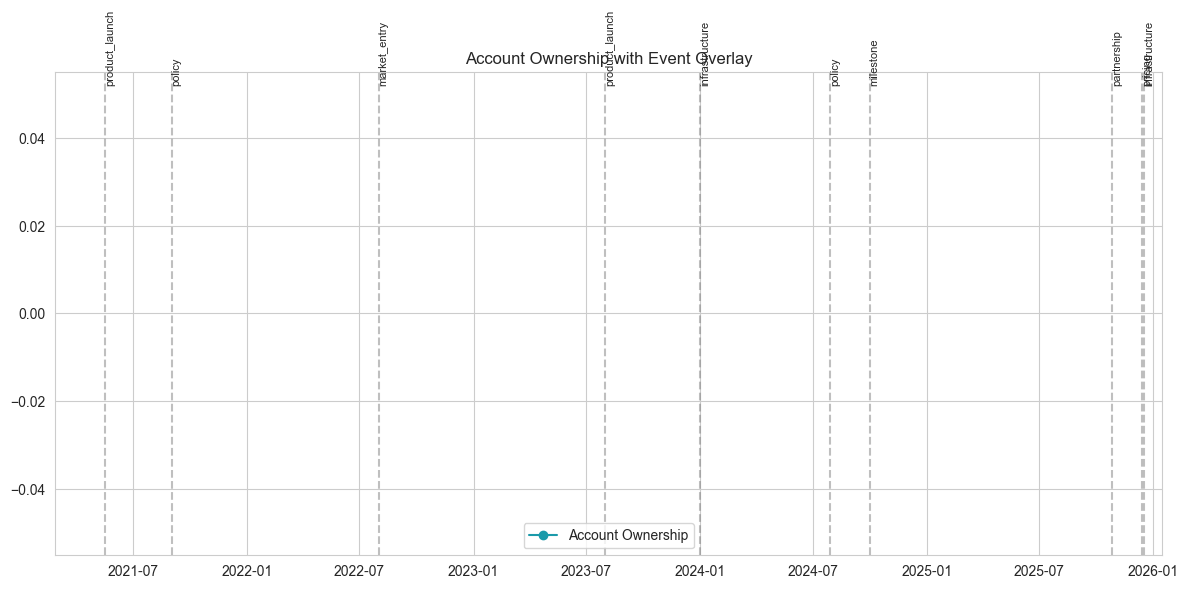

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(acc['observation_date'], acc['value_numeric'], marker='o', label='Account Ownership', color='#1B9AAA')
for _, e in events.iterrows():
    ax.axvline(e['observation_date'], color='gray', linestyle='--', alpha=0.5)
    ax.text(e['observation_date'], ax.get_ylim()[1] * 0.95, e['category'], rotation=90, fontsize=8)
ax.set_title('Account Ownership with Event Overlay')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/event_overlay.png', dpi=150)
plt.show()

## 7. Correlation Analysis

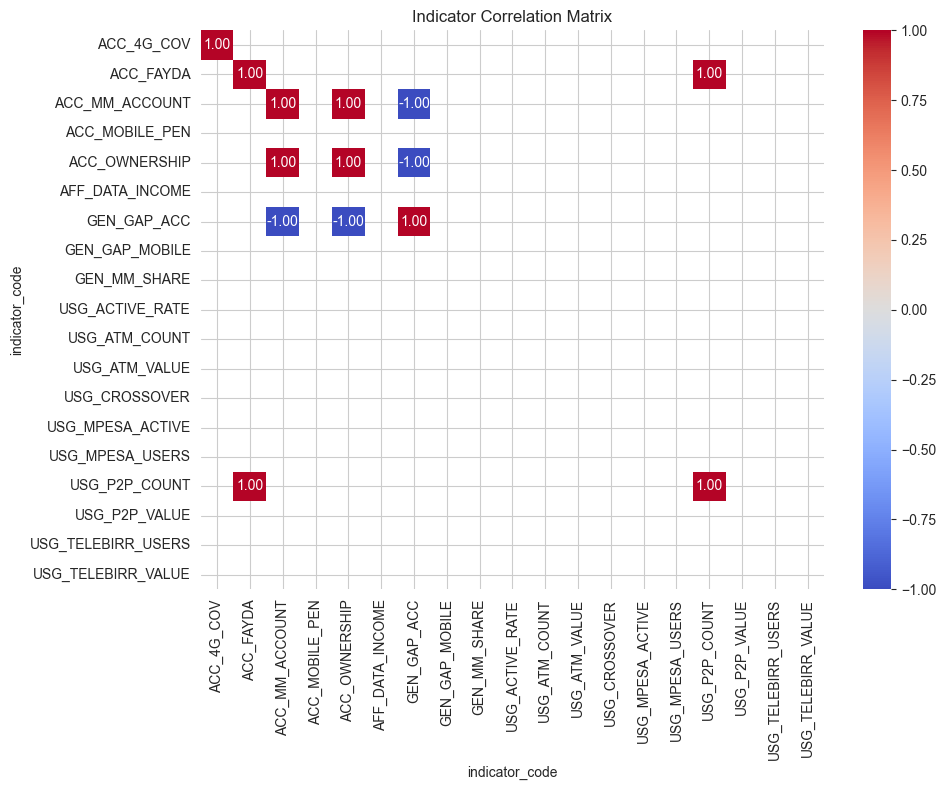

In [ ]:
pivot = obs.pivot_table(index='year', columns='indicator_code', values='value_numeric', aggfunc='mean')
corr = pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Indicator Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150)
plt.show()

**Caution:** most cells show exactly +1.00/-1.00 because most indicator
pairs only overlap in 2-3 years of data — a small-sample artifact, not a
validated relationship. Treat as directional signal only.

## 8. Event–Impact Narrative

In [ ]:
merged = merge_impact_links_with_events(impact_df, events)
print(merged[['parent_id', 'event_category', 'event_date', 'related_indicator',
              'impact_direction', 'impact_magnitude', 'lag_months']])

unlinked = find_unlinked_events(impact_df, events)
print()
print("Events with no impact_link:")
print(unlinked[['record_id', 'observation_date', 'category']] if not unlinked.empty else "None (all events linked)")

   parent_id  event_category event_date   related_indicator impact_direction  \
0   EVT_0001  product_launch 2021-05-17       ACC_OWNERSHIP         increase   
1   EVT_0001  product_launch 2021-05-17  USG_TELEBIRR_USERS         increase   
2   EVT_0001  product_launch 2021-05-17       USG_P2P_COUNT         increase   
3   EVT_0002    market_entry 2022-08-01          ACC_4G_COV         increase   
4   EVT_0002    market_entry 2022-08-01     AFF_DATA_INCOME         decrease   
5   EVT_0003  product_launch 2023-08-01     USG_MPESA_USERS         increase   
6   EVT_0003  product_launch 2023-08-01      ACC_MM_ACCOUNT         increase   
7   EVT_0004  infrastructure 2024-01-01       ACC_OWNERSHIP         increase   
8   EVT_0004  infrastructure 2024-01-01         GEN_GAP_ACC         decrease   
9   EVT_0005          policy 2024-07-29     AFF_DATA_INCOME         increase   
10  EVT_0007     partnership 2025-10-27    USG_MPESA_ACTIVE         increase   
11  EVT_0007     partnership 2025-10-27 

**Telebirr launch (May 2021) → Account Ownership:** impact_links estimate
a high-magnitude increase with a 12-month lag. Account ownership was 46% in
the 2021 survey (taken before most Telebirr adoption occurred) and 49% in
2024 — a 3pp rise, smaller than the "high" magnitude label suggests. This gap
between labeled magnitude and observed change implies Telebirr drove *usage*
(P2P transactions, transaction volume) more than *new account creation*,
since most users already had bank accounts.

**M-Pesa entry (Aug 2023) → Mobile Money Accounts:** linked to a medium-
magnitude increase in `ACC_MM_ACCOUNT` with a 6-month lag. Mobile money
account ownership reached 9.45% by 2024, up from 4.7% in 2021 — consistent
with a real but moderate effect layered on top of Telebirr's earlier base.

**NFIS-II launch (Sep 2021) → Gender Gap:** the strategy explicitly targets
halving the gender gap in account ownership from 19pp (2020) to 10pp (2025).
Observed gap in 2024 is 15pp — narrowing, but not yet on pace to hit the
2025 target with one survey cycle remaining.

**Product launches vs. policy/infrastructure events:** product launches
(Telebirr, M-Pesa) are linked mainly to Usage indicators with short lags
(3-6 months), while infrastructure and policy events (Fayda digital ID,
NFIS-II) are linked to Access and Gender indicators with much longer lags
(24-48 months). This split — fast usage adoption vs. slow structural
inclusion change — should inform the functional form chosen for
event-augmented forecasting in Task 3.

## Key Insights Summary

1. **Access has nearly quadrupled since 2011** but growth is
   decelerating: +8pp, +13pp, +11pp, then only +3pp per survey cycle
   (2011→2024), with the sharpest slowdown 2021-2024.
2. **Mobile money growth has not translated proportionally into new
   account holders** — MM accounts roughly doubled 2021-24 while overall
   ownership grew only 3pp, consistent with most new MM accounts belonging
   to people already banked.
3. **The gender gap (15pp in 2024) is only modestly narrower** than the
   19pp 2020 baseline, putting the NFIS-II target of 10pp by 2025 at risk.
4. **Data coverage is heavily skewed toward 2023-2025**; most Usage
   indicators have a single observation, limiting forecast confidence for
   Usage relative to Access.
5. **Product launches drive Usage fast; policy/infrastructure drive Access
   slowly** — evident in the lag_months split across impact_links (3-6
   months vs. 24-48 months).

## Data Limitations

- Only 6 Findex survey points span 2011-2024 for `ACC_OWNERSHIP`; most
  other indicators have 1-3 observations, insufficient for standalone trend
  estimation.
- Correlation coefficients near ±1.00 reflect small-sample artifacts
  (2-3 overlapping years per pair), not confirmed relationships.
- The GENDER pillar is not represented in `reference_codes.csv`'s four
  documented pillar codes; reconciliation is pending (see cell 3 above).
- Impact-link estimates for enrichment-added events (EVT_0006, EVT_0009)
  rely on comparable-country and precedent-based evidence rather than
  direct Ethiopian pre/post data.

## Save Enriched / Processed Data

In [ ]:
df.to_csv('../data/processed/ethiopia_fi_enriched.csv', index=False)
impact_df.to_csv('../data/processed/impact_sheet_enriched.csv', index=False)
print("Saved enriched datasets to data/processed/")

Saved enriched datasets to data/processed/
